# Week 3 — Exercise 1: Gene circuits

**27200 Data-driven Bioengineering**

Alon, *An Introduction to Systems Biology*, chapters 1–3 — simulated. You will build the three simplest
circuits in the book, watch them run, and see why evolution keeps choosing them.

| Part | Circuit | Alon | Time |
|---|---|---|---|
| 1 | Simple regulation — the baseline | ch. 1 | 5 min |
| 2 | Negative autoregulation — faster and more robust | ch. 2 | 10 min |
| 3 | Positive autoregulation — slower, and why you would want that | ch. 2 | 5 min |
| 4 | The coherent feed-forward loop — a sign-sensitive delay | ch. 3 | 10 min |
| 5 | The incoherent feed-forward loop — a pulse generator | ch. 3 | 5 min |
| 6 | *If time:* the repressilator — three repressors make a clock | ch. 6 | 5 min |

Nothing here is slow; every cell runs in under a second. **Every cell is complete and commented.** Run
it, read the plot, then read the question underneath it. The reasoning is the exercise, not the code.

> **Terms**
> **Circuit** — a small set of genes that regulate each other. **Node** = a gene/protein, **arrow** =
> "activates", **blunt arrow** ⊣ = "represses".
> **Differential equation** — a rule for how fast something changes: `dX/dt = production − removal`.
> We do not solve these by hand; we step forward in tiny time increments and let the computer add
> up the changes. That is all `simulate()` below does.
> **Steady state** (X_st) — the level at which production and removal balance, so X stops changing.
> **Response time** (T½) — how long it takes to get halfway from the old steady state to the new one.
> Alon uses this everywhere, because it is what a cell experiences: *how fast can I respond?*
> **Hill function** — the S-shaped curve describing how strongly a regulator acts as its level rises.
> `K` is the level at which it is half-effective; `n` sets how switch-like it is (n = 1 gentle,
> n = 4 nearly a step).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate(rate_of_change, y0, t_end, dt=0.005):
    '''Step a system forward in time.
    rate_of_change(t, y) must return dy/dt for every variable in y.
    Returns (times, values) where values[i] is the state at times[i].'''
    t = np.arange(0.0, t_end, dt)               # all the time points we will evaluate
    y = np.zeros((len(t), len(y0)))             # one row per time point, one column per variable
    y[0] = y0                                   # starting state
    for i in range(1, len(t)):
        dy = np.asarray(rate_of_change(t[i-1], y[i-1]))   # how fast is each variable changing right now?
        y[i] = y[i-1] + dt * dy                            # move a small step in that direction
    return t, y

def hill_act(x, K, n):
    '''Activation: rises from 0 to 1 as x grows; equals 0.5 at x = K.'''
    return x**n / (K**n + x**n)

def hill_rep(x, K, n):
    '''Repression: falls from 1 to 0 as x grows; equals 0.5 at x = K.'''
    return K**n / (K**n + x**n)

def step(condition):
    '''The "logic approximation" Alon uses: a promoter is fully on (1) or fully off (0).'''
    return 1.0 if condition else 0.0

def response_time(t, x):
    '''Time to reach halfway between the initial and final value.'''
    half = x[0] + 0.5 * (x[-1] - x[0])
    crossed = np.where(np.sign(x - half) != np.sign(x[0] - half))[0]   # first index past the halfway point
    return t[crossed[0]] if len(crossed) else np.nan

plt.rcParams.update({"figure.figsize": (9, 3.4), "axes.spines.top": False, "axes.spines.right": False})
print("ready")

ready


---
## Part 1 — Simple regulation: the baseline

A gene X is switched on at t = 0 and produced at a constant rate β. Its protein is removed at a rate
proportional to how much there is — degradation plus dilution by cell growth — with rate constant α.

$$\frac{dX}{dt} = \beta - \alpha X$$

Two things follow, and everything else in this notebook is measured against them:

- steady state **X_st = β / α** (production balances removal)
- response time **T½ = ln 2 / α** — it depends *only* on the removal rate, not on how fast you make the protein

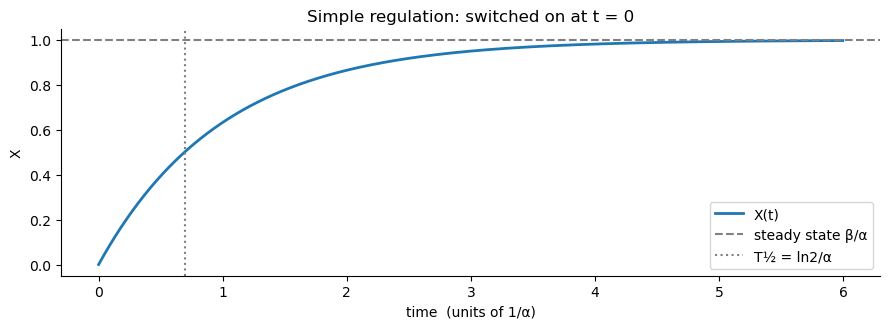

steady state    = 0.998   (theory β/α = 1.0)
response time   = 0.690   (theory ln2/α = 0.693)


In [2]:
beta, alpha = 1.0, 1.0                              # production rate, removal rate

def simple(t, y):
    X, = y                                          # unpack the single variable
    return [beta - alpha * X]                       # dX/dt

t, y = simulate(simple, y0=[0.0], t_end=6)
X = y[:, 0]

fig, ax = plt.subplots()
ax.plot(t, X, lw=2, label="X(t)")
ax.axhline(beta/alpha, ls="--", c="grey", label="steady state β/α")
ax.axvline(np.log(2)/alpha, ls=":", c="grey", label="T½ = ln2/α")
ax.set(xlabel="time  (units of 1/α)", ylabel="X", title="Simple regulation: switched on at t = 0")
ax.legend(); plt.tight_layout(); plt.show()

print(f"steady state    = {X[-1]:.3f}   (theory β/α = {beta/alpha})")
print(f"response time   = {response_time(t, X):.3f}   (theory ln2/α = {np.log(2)/alpha:.3f})")

**Question 1:** If a cell wants to respond faster, the only knob here is α. But a high
removal rate is expensive — you make protein just to destroy it. So how *do* cells respond fast?
The answer is a different circuit.

---
## Part 2 — Negative autoregulation: the same steady state, reached faster

Let X repress its own production. When X is low the promoter runs flat out; as X rises it throttles
itself back. Alon's chapter 2.

$$\frac{dX}{dt} = \frac{\beta}{1 + (X/K)^n} - \alpha X$$

To compare fairly with simple regulation we give both circuits the **same steady state and the same
α**. The autoregulated version is allowed a *higher* β — it can afford to, because it will brake itself.

> **Terms**
> **Negative autoregulation (NAR)** — a gene that represses its own transcription. The most common
> network motif in *E. coli*: about 40% of its transcription factors do this.
> **Robustness** — how little the output changes when a parameter changes. Cells cannot set β
> precisely (it fluctuates with everything from ribosome numbers to temperature), so a regulatory circuit whose
> output ignores β is worth the cost.

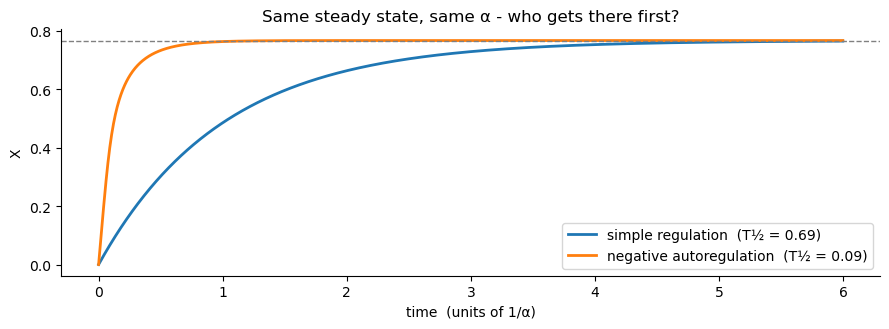

NAR reaches half its steady state 8.1x faster than simple regulation.
It sprints at full production while X is low, then brakes as X approaches K.


In [3]:
alpha, K, n = 1.0, 0.5, 4                   # removal rate; repression threshold; steepness
beta_nar = 5.0                              # NAR gets a strong promoter...
X_st_nar = None                             # ...and we will read its steady state off the simulation

def nar(t, y):
    X, = y
    return [beta_nar * hill_rep(X, K, n) - alpha * X]     # production throttled by X itself

t, y = simulate(nar, y0=[0.0], t_end=6)
X_nar = y[:, 0]
X_st_nar = X_nar[-1]

# Simple regulation tuned to reach the SAME steady state, with the same alpha
beta_simple = X_st_nar * alpha
t, y = simulate(lambda t, y: [beta_simple - alpha * y[0]], y0=[0.0], t_end=6)
X_simple = y[:, 0]

fig, ax = plt.subplots()
ax.plot(t, X_simple, lw=2, label=f"simple regulation  (T½ = {response_time(t, X_simple):.2f})")
ax.plot(t, X_nar,    lw=2, label=f"negative autoregulation  (T½ = {response_time(t, X_nar):.2f})")
ax.axhline(X_st_nar, ls="--", c="grey", lw=1)
ax.set(xlabel="time  (units of 1/α)", ylabel="X", title="Same steady state, same α - who gets there first?")
ax.legend(); plt.tight_layout(); plt.show()

speedup = response_time(t, X_simple) / response_time(t, X_nar)
print(f"NAR reaches half its steady state {speedup:.1f}x faster than simple regulation.")
print("It sprints at full production while X is low, then brakes as X approaches K.")

### Question 2.1 — where does the speed come from?

**Both circuits have the same α, so removal is identical. Where does NAR's extra speed come from?**

Look at the two curves at t ≈ 0.2. Both circuits have the same α, so removal is identical. The NAR
curve is steeper because its *production* is higher while X is still small — it uses a strong promoter
and relies on repression to stop it overshooting. Simple regulation cannot do that: a strong promoter
would just give a higher steady state.

**Alon's point:** the response time of simple regulation is fixed by α alone (Part 1). NAR breaks that
link. In the limit of very strong repression the response time becomes ~ K/β, set by how fast you can
*produce*, not how fast you *remove*.

### Question 2.2 — robustness

**Production rates are noisy: β varies from cell to cell. If β halves or doubles, how much does each
circuit's steady state change?** The next cell measures it — read the table, then the explanation
under it.

In [4]:
def steady_state(rate_fn, t_end=15):
    return simulate(rate_fn, y0=[0.0], t_end=t_end)[1][-1, 0]

results = []
for factor in [0.5, 1.0, 2.0]:                    # production rate at half, nominal, double
    b = beta_nar * factor
    x_nar = steady_state(lambda t, y: [b * hill_rep(y[0], K, n) - alpha * y[0]])
    b2 = beta_simple * factor
    x_simple = steady_state(lambda t, y: [b2 - alpha * y[0]])
    results.append((factor, x_simple, x_nar))

print(f"{'β multiplier':>13} {'simple X_st':>12} {'NAR X_st':>10}")
for f, xs, xn in results:
    print(f"{f:>13.1f} {xs:>12.3f} {xn:>10.3f}")
print("\nSimple regulation passes the change in β straight through to the output.")
print("NAR barely moves: its steady state is pinned near K by the repression threshold,")
print("which is set by the DNA-binding affinity - a property of the protein, not of the cell's state.")

 β multiplier  simple X_st   NAR X_st
          0.5        0.383      0.650
          1.0        0.767      0.767
          2.0        1.533      0.893

Simple regulation passes the change in β straight through to the output.
NAR barely moves: its steady state is pinned near K by the repression threshold,
which is set by the DNA-binding affinity - a property of the protein, not of the cell's state.


---
## Part 3 — Positive autoregulation: slower, on purpose

Now let X *activate* its own production. A small leak β₀ gets things started; once X passes K, it
drives its own expression up.

$$\frac{dX}{dt} = \beta_0 + \beta \frac{(X/K)^n}{1 + (X/K)^n} - \alpha X$$

Alon: positive autoregulation **slows** the response. That sounds like a defect. It is a feature —
slow, committed switches are what you want for decisions that should not flicker: differentiation,
sporulation, lysogeny.

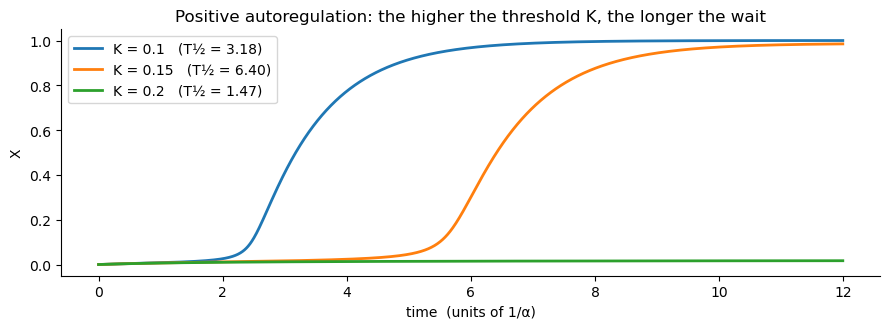

In [5]:
alpha, beta, beta0, n = 1.0, 1.0, 0.01, 2       # leak beta0 is 1% of full production

fig, ax = plt.subplots()
for K in [0.10, 0.15, 0.20]:                     # three activation thresholds
    def par(t, y, K=K):
        X, = y
        return [beta0 + beta * hill_act(X, K, n) - alpha * X]
    t, y = simulate(par, y0=[0.0], t_end=12)
    ax.plot(t, y[:, 0], lw=2, label=f"K = {K}   (T½ = {response_time(t, y[:, 0]):.2f})")
ax.set(xlabel="time  (units of 1/α)", ylabel="X", title="Positive autoregulation: the higher the threshold K, the longer the wait")
ax.legend(); plt.tight_layout(); plt.show()

### Question 3.1 — why slower, and why bother?

**Why does a higher threshold K make the response slower — and why would a cell ever want a slow
switch?**

Compare the shapes with Parts 1 and 2. Positive autoregulation is **sigmoidal**: nothing much happens
until the leak has pushed X past K, then it takes off. Raising K lengthens the wait almost linearly —
the cell is stuck at the leak rate until it crosses the threshold.

That lag is the point. A circuit that responds slowly to a signal will *not* respond to a brief
fluctuation of the signal at all. Chapter 3 shows a cheaper way to get the same filtering.

---
## Part 4 — The coherent feed-forward loop: a sign-sensitive delay

Three nodes. X activates Y, X activates Z, and Y activates Z. Z's promoter needs **both** X and Y
(AND logic). This is the **coherent type-1 FFL**, and it is the most common three-node motif in
*E. coli* and yeast.

We use Alon's logic approximation: a promoter is on (1) if its inputs are above threshold, off (0)
otherwise. X is present but inactive until a signal S_x arrives and makes it active.

> **Terms**
> **Coherent** — every path from X to Z has the same overall sign (here: all activation).
> **Incoherent** — the direct and indirect paths have opposite signs (Part 5).
> **AND gate** — Z needs both inputs. **OR gate** — either will do.
> **Sign-sensitive delay** — the circuit delays one transition (OFF→ON) but not the other (ON→OFF).

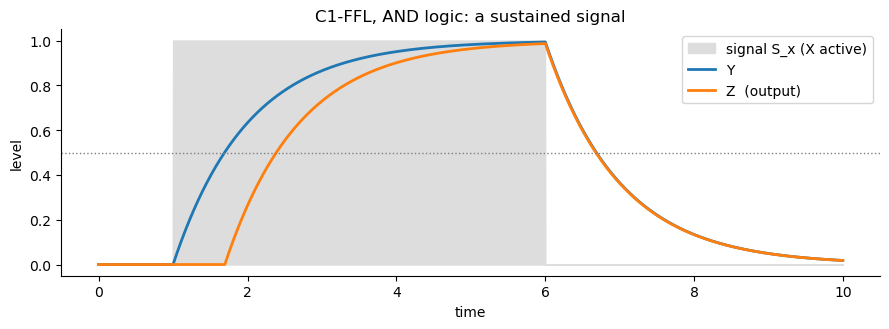

In [6]:
alpha = 1.0
beta_y, beta_z = 1.0, 1.0
K_xy = K_xz = 0.5                  # thresholds at which active X switches Y and Z on
K_yz = 0.5                         # threshold at which Y contributes to Z

def c1_ffl(t, y, Sx):
    Y, Z = y
    X_active = Sx(t)                                          # X* = 1 while the signal is present, else 0
    dY = beta_y * step(X_active > K_xy) - alpha * Y
    dZ = beta_z * step(X_active > K_xz and Y > K_yz) - alpha * Z      # AND: needs X* and enough Y
    return [dY, dZ]

def run_signal(Sx, t_end, title):
    t, y = simulate(lambda t, y: c1_ffl(t, y, Sx), y0=[0.0, 0.0], t_end=t_end)
    fig, ax = plt.subplots()
    ax.fill_between(t, 0, [Sx(ti) for ti in t], color="#dddddd", label="signal S_x (X active)")
    ax.plot(t, y[:, 0], lw=2, label="Y")
    ax.plot(t, y[:, 1], lw=2, label="Z  (output)")
    ax.axhline(K_yz, ls=":", c="grey", lw=1)
    ax.set(xlabel="time", ylabel="level", title=title); ax.legend(loc="upper right")
    plt.tight_layout(); plt.show()
    return t, y

# A long ON step, then OFF.
t, y = run_signal(lambda t: 1.0 if 1 <= t < 6 else 0.0, 10, "C1-FFL, AND logic: a sustained signal")

### Read the plot

- **OFF → ON**: the signal arrives at t = 1, but Z does not start until Y has climbed past its
  threshold K_yz. That is the **delay**, and its length is set by how fast Y accumulates.
- **ON → OFF**: the signal stops at t = 6 and Z switches off *immediately*, because the AND gate
  loses X* at once — it does not have to wait for Y to decay.

One transition is delayed, the other is not. Hence *sign-sensitive*. Now the payoff:

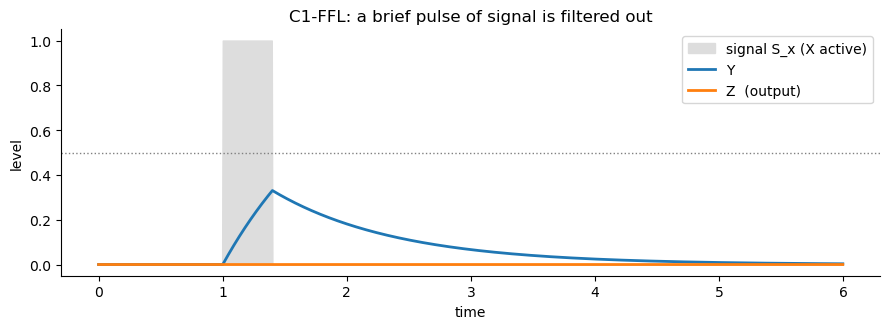

maximum Z reached during the pulse: 0.000   (compare: full ON steady state = 1.0)


In [7]:
# A brief blip of signal, shorter than the delay. Does Z respond?
t, y = run_signal(lambda t: 1.0 if 1 <= t < 1.4 else 0.0, 6, "C1-FFL: a brief pulse of signal is filtered out")
print(f"maximum Z reached during the pulse: {y[:, 1].max():.3f}   (compare: full ON steady state = {beta_z/alpha})")

### Question 4.1 — what is the circuit for?

**A signal arrived and lasted 0.4 time units. Z never responded at all. What is the circuit doing,
and why is that useful to a cell?**

The short pulse never produces any Z. The signal switched off before Y had accumulated enough to
open the AND gate. **The C1-FFL is a persistence detector**: it responds only to signals that last.
For a bacterium deciding whether to build the machinery to eat a new sugar, that is worth a lot —
sugar that appears for two seconds is not worth a transcriptional programme.

### Question 4.2 — what changes with OR logic?

**Change `and` to `or` in the Z equation and rerun both cells. Which transition is delayed now?**

With OR, Z turns on immediately with X*
and the *OFF* transition becomes the delayed one (Z stays on until Y decays). Same wiring, opposite
sign-sensitivity. Alon chapter 3 shows both are used, for different jobs.

---
## Part 5 — The incoherent feed-forward loop: a pulse generator

Same three nodes, one sign flipped: X activates Y and Z, but **Y represses Z**. The direct path says
"go", the indirect path says "stop" a little later. This is the **incoherent type-1 FFL**.

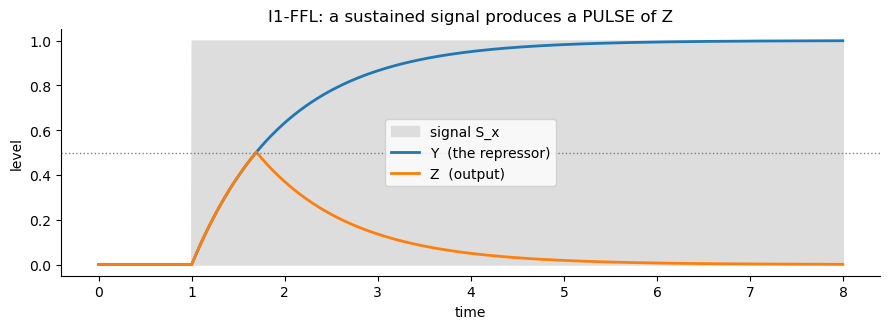

Z peaks at 0.50 then falls back to 0.00 while the signal is still on.


In [8]:
def i1_ffl(t, y, Sx):
    Y, Z = y
    X_active = Sx(t)
    dY = beta_y * step(X_active > K_xy) - alpha * Y
    dZ = beta_z * step(X_active > K_xz and Y < K_yz) - alpha * Z    # AND: X* present AND Y still low
    return [dY, dZ]

Sx = lambda t: 1.0 if t >= 1 else 0.0        # signal switches on at t = 1 and stays on
t, y = simulate(lambda t, y: i1_ffl(t, y, Sx), y0=[0.0, 0.0], t_end=8)

fig, ax = plt.subplots()
ax.fill_between(t, 0, [Sx(ti) for ti in t], color="#dddddd", label="signal S_x")
ax.plot(t, y[:, 0], lw=2, label="Y  (the repressor)")
ax.plot(t, y[:, 1], lw=2, label="Z  (output)")
ax.axhline(K_yz, ls=":", c="grey", lw=1)
ax.set(xlabel="time", ylabel="level", title="I1-FFL: a sustained signal produces a PULSE of Z")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Z peaks at {y[:, 1].max():.2f} then falls back to {y[-1, 1]:.2f} while the signal is still on.")

### Question 5.1 — a pulse from a step

**The signal never switches off. Why does Z rise and then fall anyway?**

The signal never goes away, yet Z rises and then falls. Z is produced as soon as X* appears, and shut
down as soon as Y accumulates past K_yz. A step in becomes a pulse out.

Two uses Alon draws out: **pulse generation** (a burst of activity, then adaptation — like your eye
adapting to a bright room), and **response acceleration** — because Z overshoots on the way up, it
reaches its final level faster than simple regulation would. Same trick as NAR, achieved with a third
gene instead of self-repression.

### Question 5.2 — the I/O table

**For the AND version of the I1-FFL, what is Z at steady state for each of the four combinations of
S_x and S_y?** Work it out from the wiring before looking at the table.

| S_x | S_y (Y active?) | Z at steady state |
|---|---|---|
| 0 | 0 | 0 — no X*, gate closed |
| 0 | 1 | 0 |
| 1 | 0 | **1** — X* present, Y cannot repress |
| 1 | 1 | 0 — Y represses |

The pulse in the plot is the trajectory from (1, 0) to (1, 1) as Y switches itself on.

---
## Part 6 — *If time:* the repressilator

Not in chapters 1–4 — this is chapter 6 — but it is built from exactly the pieces above and it is
the most famous synthetic circuit ever made (Elowitz & Leibler, *Nature* 2000). Three repressors in
a ring: A ⊣ B ⊣ C ⊣ A. Each protein represses the next; there is no stable state, so the system
oscillates.

We use the original paper's equations, with mRNA and protein for each gene (six variables), and its
parameter values.

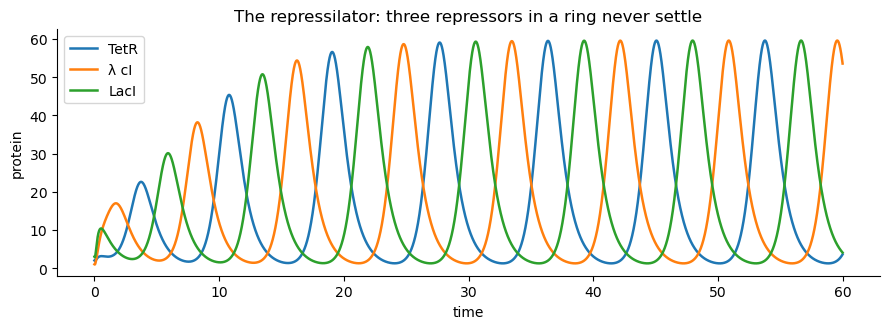

oscillation period ≈ 8.7 time units


In [9]:
# Elowitz & Leibler 2000, dimensionless form and parameters
alpha_r, alpha0, beta_r, n_r = 216.0, 0.216, 5.0, 2.0

def repressilator(t, y):
    m1, m2, m3, p1, p2, p3 = y            # mRNAs and proteins for the three genes
    # each mRNA is repressed by the PREVIOUS protein in the ring, with a small leak alpha0
    dm1 = alpha_r / (1 + p3**n_r) + alpha0 - m1
    dm2 = alpha_r / (1 + p1**n_r) + alpha0 - m2
    dm3 = alpha_r / (1 + p2**n_r) + alpha0 - m3
    # each protein is made from its mRNA and removed at rate beta_r
    dp1 = beta_r * (m1 - p1)
    dp2 = beta_r * (m2 - p2)
    dp3 = beta_r * (m3 - p3)
    return [dm1, dm2, dm3, dp1, dp2, dp3]

t, y = simulate(repressilator, y0=[1, 0, 0, 2, 1, 3], t_end=60, dt=0.002)

fig, ax = plt.subplots()
for i, name in enumerate(["TetR", "λ cI", "LacI"]):
    ax.plot(t, y[:, 3 + i], lw=1.8, label=name)
ax.set(xlabel="time", ylabel="protein", title="The repressilator: three repressors in a ring never settle")
ax.legend(); plt.tight_layout(); plt.show()

# period from the peaks of protein 1, ignoring the transient
p = y[:, 3]; late = t > 20
peaks = np.where((p[1:-1] > p[:-2]) & (p[1:-1] > p[2:]) & late[1:-1])[0] + 1
print(f"oscillation period ≈ {np.mean(np.diff(t[peaks])):.1f} time units")

### Question 6.1 — what makes it a clock?

**Set `n_r = 1` and rerun. Does the ring still oscillate? Why not?**

The oscillation dies out — the system settles to a steady state. Repression
needs to be **cooperative** (n > 1) for the ring to keep going; the nonlinearity is what makes it a
clock rather than a thermostat. This is the same reason positive autoregulation in Part 3 used n = 2.

---
## What to take away

1. **Simple regulation's speed is fixed by degradation.** Every other circuit is a way around that.
2. **Negative autoregulation** buys speed and robustness with a strong promoter that throttles itself.
3. **Positive autoregulation** buys commitment — slow, sigmoidal, hard to flicker.
4. **The coherent FFL** is a filter: it ignores signals that do not persist, and it does so
   asymmetrically (delay on, instant off — or the reverse with OR logic).
5. **The incoherent FFL** turns a step into a pulse, and accelerates responses the way NAR does.
6. **Three of the same part in a ring** gives you a clock, if the parts are nonlinear enough.

Every one of these is a *motif* — a pattern that appears in real networks far more often than chance
predicts. Exercise 2 counts them.